<a href="https://colab.research.google.com/github/Khushmandeep-Kaur-Dhaliwal/ml-project-restaurant-rating-prediction/blob/main/restaurant_rating_prediction_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
##import libraries

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

In [ ]:
## load dataset
data = pd.read_csv('/content/display.csv')

In [ ]:
data.shape

(24151, 84)

In [ ]:
data.head()

,Name,Menu,Delivery,Booking,Type,City,No_of_Best_Sellers,No_of_Varieties,Cost_Per_Person,Rating,Category,Price_Category,Afghani,African,American,Andhra,Arabian,Asian,Assamese,Awadhi,BBQ,Bakery,Belgian,Bengali,Beverages,Bihari,Bohri,British,Burmese,Cantonese,Chettinad,Chinese,Continental,Desserts,European,Fast Food,French,German,Goan,Greek,...,Iranian,Italian,Japanese,Jewish,Kashmiri,Kerala,Konkan,Korean,Lebanese,Lucknowi,Maharashtrian,Malaysian,Mangalorean,Mediterranean,Mexican,Middle Eastern,Modern Indian,Mughlai,Naga,Nepalese,North Eastern,North Indian,Oriya,Parsi,Portuguese,Rajasthani,Russian,Seafood,Sindhi,Singaporean,South American,South Indian,Spanish,Sri Lankan,Tamil,Thai,Tibetan,Turkish,Vegan,Vietnamese
0,Jalsa,No,Yes,Yes,Buffet,Banashankari,7,3,400.0,4.1,Excellent,Affordable,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,Spice Elephant,No,Yes,No,Buffet,Banashankari,7,3,400.0,4.1,Excellent,Affordable,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
2,San Churro Cafe,No,Yes,No,Buffet,Banashankari,7,3,400.0,3.8,Good,Affordable,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,Addhuri Udupi Bhojana,No,No,No,Buffet,Banashankari,1,2,150.0,3.7,Good,Resonable,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
4,Grand Village,No,No,No,Buffet,Banashankari,2,2,300.0,3.8,Good,Affordable,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24151 entries, 0 to 24150
Data columns (total 84 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                24151 non-null  object 
 1   Menu                24151 non-null  object 
 2   Delivery            24151 non-null  object 
 3   Booking             24151 non-null  object 
 4   Type                24151 non-null  object 
 5   City                24151 non-null  object 
 6   No_of_Best_Sellers  24151 non-null  int64  
 7   No_of_Varieties     24151 non-null  int64  
 8   Cost_Per_Person     24151 non-null  float64
 9   Rating              24151 non-null  float64
 10  Category            24151 non-null  object 
 11  Price_Category      24151 non-null  object 
 12  Afghani             24151 non-null  int64  
 13  African             24151 non-null  int64  
 14  American            24151 non-null  int64  
 15  Andhra              24151 non-null  int64  
 16  Arab

In [ ]:
data.describe()

,No_of_Best_Sellers,No_of_Varieties,Cost_Per_Person,Rating,Afghani,African,American,Andhra,Arabian,Asian,Assamese,Awadhi,BBQ,Bakery,Belgian,Bengali,Beverages,Bihari,Bohri,British,Burmese,Cantonese,Chettinad,Chinese,Continental,Desserts,European,Fast Food,French,German,Goan,Greek,Gujarati,Healthy Food,Hyderabadi,Indonesian,Iranian,Italian,Japanese,Jewish,Kashmiri,Kerala,Konkan,Korean,Lebanese,Lucknowi,Maharashtrian,Malaysian,Mangalorean,Mediterranean,Mexican,Middle Eastern,Modern Indian,Mughlai,Naga,Nepalese,North Eastern,North Indian,Oriya,Parsi,Portuguese,Rajasthani,Russian,Seafood,Sindhi,Singaporean,South American,South Indian,Spanish,Sri Lankan,Tamil,Thai,Tibetan,Turkish,Vegan,Vietnamese
count,24151.000000,24151.000000,24151.000000,24151.000000,24151.000000,24151.000000,24151.000000,24151.000000,24151.000000,24151.000000,24151.000000,24151.000000,24151.000000,24151.00000,24151.000000,24151.000000,24151.000000,24151.000000,24151.000000,24151.000000,24151.000000,24151.000000,24151.000000,24151.000000,24151.000000,24151.000000,24151.000000,24151.000000,24151.000000,24151.000000,24151.000000,24151.000000,24151.000000,24151.000000,24151.000000,24151.000000,24151.000000,24151.000000,24151.000000,24151.000000,24151.00000,24151.000000,24151.000000,24151.000000,24151.000000,24151.000000,24151.000000,24151.000000,24151.000000,24151.000000,24151.000000,24151.000000,24151.000000,24151.000000,24151.000000,24151.000000,24151.000000,24151.000000,24151.000000,24151.000000,24151.000000,24151.000000,24151.000000,24151.000000,24151.000000,24151.000000,24151.000000,24151.000000,24151.000000,24151.000000,24151.000000,24151.000000,24151.000000,24151.000000,24151.000000,24151.000000
mean,5.158337,2.838309,370.178150,3.885230,0.002319,0.000704,0.049232,0.039212,0.024512,0.042400,0.000828,0.000621,0.042069,0.03238,0.000124,0.012960,0.209639,0.001159,0.000041,0.000290,0.001863,0.000248,0.006418,0.332905,0.174941,0.125958,0.025837,0.289181,0.002774,0.000290,0.004141,0.001408,0.002691,0.077471,0.006087,0.003312,0.001035,0.149311,0.014161,0.000248,0.00058,0.027618,0.003147,0.005176,0.004306,0.001822,0.002774,0.004223,0.016024,0.020372,0.017225,0.003023,0.005590,0.043104,0.001035,0.001905,0.001573,0.449588,0.002857,0.000952,0.000455,0.005134,0.000248,0.051841,0.000166,0.001946,0.000414,0.229431,0.001408,0.000621,0.000166,0.033373,0.007536,0.002443,0.000248,0.006418
std,2.490716,1.390259,257.976498,0.438061,0.048098,0.026522,0.216356,0.194102,0.154637,0.201504,0.028766,0.024914,0.200750,0.17701,0.011145,0.113105,0.407060,0.034031,0.006435,0.017023,0.043126,0.015760,0.079856,0.471263,0.379924,0.331808,0.158653,0.453391,0.052599,0.017023,0.064216,0.037495,0.051810,0.267343,0.077781,0.057460,0.032158,0.356402,0.118156,0.015760,0.02407,0.163879,0.056010,0.071758,0.065482,0.042645,0.052599,0.064852,0.125571,0.141272,0.130111,0.054897,0.074557,0.203095,0.032158,0.043602,0.039636,0.497462,0.053376,0.030846,0.021337,0.071472,0.015760,0.221709,0.012869,0.044072,0.020345,0.420476,0.037495,0.024914,0.012869,0.179613,0.086484,0.049367,0.015760,0.079856
min,0.000000,1.000000,20.000000,1.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.000000,2.000000,200.000000,3.700000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000

In [ ]:
##checking null values
data.isnull().sum()

,0
Name,0
Menu,0
Delivery,0
Booking,0
Type,0
...,...
Thai,0
Tibetan,0
Turkish,0
Vegan,0


In [ ]:
data.columns

Index(['Name', 'Menu', 'Delivery', 'Booking', 'Type', 'City',
       'No_of_Best_Sellers', 'No_of_Varieties', 'Cost_Per_Person', 'Rating',
       'Category', 'Price_Category', 'Afghani', 'African', 'American',
       'Andhra', 'Arabian', 'Asian', 'Assamese', 'Awadhi', 'BBQ', 'Bakery',
       'Belgian', 'Bengali', 'Beverages', 'Bihari', 'Bohri', 'British',
       'Burmese', 'Cantonese', 'Chettinad', 'Chinese', 'Continental',
       'Desserts', 'European', 'Fast Food', 'French', 'German', 'Goan',
       'Greek', 'Gujarati', 'Healthy Food', 'Hyderabadi', 'Indonesian',
       'Iranian', 'Italian', 'Japanese', 'Jewish', 'Kashmiri', 'Kerala',
       'Konkan', 'Korean', 'Lebanese', 'Lucknowi', 'Maharashtrian',
       'Malaysian', 'Mangalorean', 'Mediterranean', 'Mexican',
       'Middle Eastern', 'Modern Indian', 'Mughlai', 'Naga', 'Nepalese',
       'North Eastern', 'North Indian', 'Oriya', 'Parsi', 'Portuguese',
       'Rajasthani', 'Russian', 'Seafood', 'Sindhi', 'Singaporean',
       'Sou

<Axes: xlabel='Rating', ylabel='Count'>

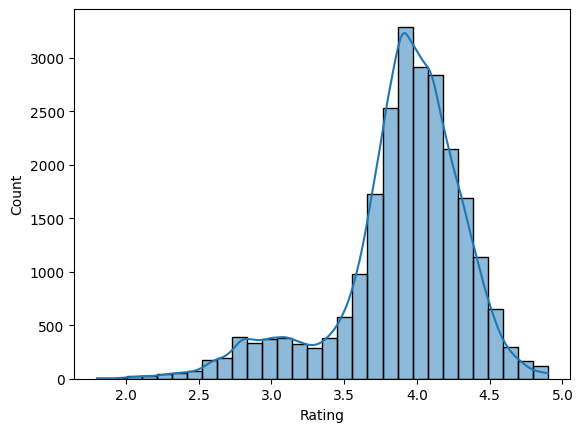

In [ ]:
sns.histplot(data['Rating'],bins = 30,kde = True)

In [ ]:
data[['Menu','Delivery','Booking']] = data[['Menu','Delivery','Booking']].replace({'Yes':1, 'No':0}).astype(int)

In [ ]:
data['Type'].value_counts()

,count
Type,
Delivery,11352
Dine-out,8270
Desserts,1321
Cafes,1037
Drinks & nightlife,891
Buffet,749
Pubs and bars,531


In [ ]:
data['Category'].value_counts()

,count
Category,
Excellent,11961
Good,10858
Average,1167
Poor,165


In [ ]:
data['Price_Category'].value_counts()

,count
Price_Category,
Resonable,9127
Affordable,8807
Expensive,4736
Cheap,1481


In [ ]:
data = pd.get_dummies(data, columns=['Type', 'Category', 'Price_Category'])

In [ ]:
data.head()

,Name,Menu,Delivery,Booking,City,No_of_Best_Sellers,No_of_Varieties,Cost_Per_Person,Rating,Afghani,African,American,Andhra,Arabian,Asian,Assamese,Awadhi,BBQ,Bakery,Belgian,Bengali,Beverages,Bihari,Bohri,British,Burmese,Cantonese,Chettinad,Chinese,Continental,Desserts,European,Fast Food,French,German,Goan,Greek,Gujarati,Healthy Food,Hyderabadi,...,Middle Eastern,Modern Indian,Mughlai,Naga,Nepalese,North Eastern,North Indian,Oriya,Parsi,Portuguese,Rajasthani,Russian,Seafood,Sindhi,Singaporean,South American,South Indian,Spanish,Sri Lankan,Tamil,Thai,Tibetan,Turkish,Vegan,Vietnamese,Type_Buffet,Type_Cafes,Type_Delivery,Type_Desserts,Type_Dine-out,Type_Drinks & nightlife,Type_Pubs and bars,Category_Average,Category_Excellent,Category_Good,Category_Poor,Price_Category_Affordable,Price_Category_Cheap,Price_Category_Expensive,Price_Category_Resonable
0,Jalsa,0,1,1,Banashankari,7,3,400.0,4.1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,True,False,False,False,False,False,False,False,True,False,False,True,False,False,False
1,Spice Elephant,0,1,0,Banashankari,7,3,400.0,4.1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,True,False,False,False,False,False,False,False,True,False,False,True,False,False,False
2,San Churro Cafe,0,1,0,Banashankari,7,3,400.0,3.8,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,True,False,False,False,False,False,False,False,False,True,False,True,False,False,False
3,Addhuri Udupi Bhojana,0,0,0,Banashankari,1,2,150.0,3.7,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,True,False,False,False,False,False,False,False,False,True,False,False,False,False,True
4,Grand Village,0,0,0,Banashankari,2,2,300.0,3.8,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,True,False,False,False,False,False,False,False,False,True,False,True,False,False,False


In [ ]:
for col in data.columns:
    # Only attempt to convert columns that are not of 'object' dtype.
    # This will convert boolean columns (from get_dummies) to 0s and 1s,
    # and float columns (like 'Cost_Per_Person' and 'Rating') to integers by truncation.
    if data[col].dtype != 'object':
        data[col] = data[col].astype(int)

In [ ]:
data.head()

,Name,Menu,Delivery,Booking,City,No_of_Best_Sellers,No_of_Varieties,Cost_Per_Person,Rating,Afghani,African,American,Andhra,Arabian,Asian,Assamese,Awadhi,BBQ,Bakery,Belgian,Bengali,Beverages,Bihari,Bohri,British,Burmese,Cantonese,Chettinad,Chinese,Continental,Desserts,European,Fast Food,French,German,Goan,Greek,Gujarati,Healthy Food,Hyderabadi,...,Middle Eastern,Modern Indian,Mughlai,Naga,Nepalese,North Eastern,North Indian,Oriya,Parsi,Portuguese,Rajasthani,Russian,Seafood,Sindhi,Singaporean,South American,South Indian,Spanish,Sri Lankan,Tamil,Thai,Tibetan,Turkish,Vegan,Vietnamese,Type_Buffet,Type_Cafes,Type_Delivery,Type_Desserts,Type_Dine-out,Type_Drinks & nightlife,Type_Pubs and bars,Category_Average,Category_Excellent,Category_Good,Category_Poor,Price_Category_Affordable,Price_Category_Cheap,Price_Category_Expensive,Price_Category_Resonable
0,Jalsa,0,1,1,Banashankari,7,3,400,4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,1,0,0,0
1,Spice Elephant,0,1,0,Banashankari,7,3,400,4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,1,0,0,0
2,San Churro Cafe,0,1,0,Banashankari,7,3,400,3,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,1,0,0,0
3,Addhuri Udupi Bhojana,0,0,0,Banashankari,1,2,150,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1
4,Grand Village,0,0,0,Banashankari,2,2,300,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,1,0,0,0


In [ ]:
data = pd.get_dummies(data, columns=['Name', 'City'])

In [ ]:
data.head()

,Menu,Delivery,Booking,No_of_Best_Sellers,No_of_Varieties,Cost_Per_Person,Rating,Afghani,African,American,Andhra,Arabian,Asian,Assamese,Awadhi,BBQ,Bakery,Belgian,Bengali,Beverages,Bihari,Bohri,British,Burmese,Cantonese,Chettinad,Chinese,Continental,Desserts,European,Fast Food,French,German,Goan,Greek,Gujarati,Healthy Food,Hyderabadi,Indonesian,Iranian,...,Name_Zodiac,Name_Zodiac - Fortune Select JP Cosmos Hotel,Name_Zoey's,Name_Zyara,Name_alt,Name_b CafÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂ© - Shangri-La Hotel,Name_eat.fit,Name_i-Bar - The Park Bangalore,Name_nu.tree,Name_re:cess - Hilton Bangalore Embassy GolfLinks,City_BTM,City_Banashankari,City_Bannerghatta Road,City_Basavanagudi,City_Bellandur,City_Brigade Road,City_Brookefield,City_Church Street,City_Electronic City,City_Frazer Town,City_HSR,City_Indiranagar,City_JP Nagar,City_Jayanagar,City_Kalyan Nagar,City_Kammanahalli,City_Koramangala 4th Block,City_Koramangala 5th Block,City_Koramangala 6th Block,City_Koramangala 7th Block,City_Lavelle Road,City_MG Road,City_Malleshwaram,City_Marathahalli,City_New BEL Road,City_Old Airport Road,City_Rajajinagar,City_Residency Road,City_Sarjapur Road,City_Whitefield
0,0,1,1,7,3,400,4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,0,1,0,7,3,400,4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,0,1,0,7,3,400,3,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,0,0,0,1,2,150,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,0,0,0,2,2,300,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [ ]:
for col in data.columns:
    if data[col].dtype != 'object':
        data[col] = data[col].astype(int)

In [ ]:
data.head()

,Menu,Delivery,Booking,No_of_Best_Sellers,No_of_Varieties,Cost_Per_Person,Rating,Afghani,African,American,Andhra,Arabian,Asian,Assamese,Awadhi,BBQ,Bakery,Belgian,Bengali,Beverages,Bihari,Bohri,British,Burmese,Cantonese,Chettinad,Chinese,Continental,Desserts,European,Fast Food,French,German,Goan,Greek,Gujarati,Healthy Food,Hyderabadi,Indonesian,Iranian,...,Name_Zodiac,Name_Zodiac - Fortune Select JP Cosmos Hotel,Name_Zoey's,Name_Zyara,Name_alt,Name_b CafÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂ© - Shangri-La Hotel,Name_eat.fit,Name_i-Bar - The Park Bangalore,Name_nu.tree,Name_re:cess - Hilton Bangalore Embassy GolfLinks,City_BTM,City_Banashankari,City_Bannerghatta Road,City_Basavanagudi,City_Bellandur,City_Brigade Road,City_Brookefield,City_Church Street,City_Electronic City,City_Frazer Town,City_HSR,City_Indiranagar,City_JP Nagar,City_Jayanagar,City_Kalyan Nagar,City_Kammanahalli,City_Koramangala 4th Block,City_Koramangala 5th Block,City_Koramangala 6th Block,City_Koramangala 7th Block,City_Lavelle Road,City_MG Road,City_Malleshwaram,City_Marathahalli,City_New BEL Road,City_Old Airport Road,City_Rajajinagar,City_Residency Road,City_Sarjapur Road,City_Whitefield
0,0,1,1,7,3,400,4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,1,0,7,3,400,4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,1,0,7,3,400,3,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,1,2,150,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,2,2,300,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [ ]:
##define feature and target
X = data.drop('Rating', axis=1)
y = data['Rating']

In [ ]:
##train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
scaler = StandardScaler()

In [ ]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test)

In [ ]:
model = LinearRegression()

In [ ]:
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
##model evaluation
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R2 Score:", r2)

Mean Squared Error: 3.3385576162387765e-05
R2 Score: 0.9999060065264916


In [ ]:
n = X_test.shape[0]
p = X_test.shape[1]
adjusted_r2 = 1 - (1-r2)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)
print("Adjusted R2 Score:", adjusted_r2)

Adjusted R2 Score: 0.999666184943349
